Import Data

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('../data/transaction_1.csv', index_col=0)
print(df1.shape)
df1.head()

(250001, 15)


,TransactionID,DateTime,Date_Key,Branch,Customer_ID,SKU_ID,SKU,Brand,SKU_Category,Qty,NormalPrice,DiscountedPrice,DiscountPercentage,Total_Price,Promo_Category
0,T024913,2025-09-26 15:16:25,20250926,Surabaya,C40615,S007,Richeese Siip Keju 20g,Richeese,Extruded Snack,4,3000.0,3000.0,0.00,12000.0,No Promo
1,T043161,2025-08-03 16:55:20,20250803,Bandung,C04119,S020,Richeese Mi Instan Goreng,Richeese,Mi Instan,3,3500.0,3300.0,0.05,9900.0,Promo Normal
2,T043161,2025-08-03 16:55:20,20250803,Bandung,C04119,S012,Nabati Biskuit Rasa Cokelat,Richoco,Biskuit,1,5000.0,4800.0,0.05,4800.0,Promo Normal
3,T089523,2025-09-18 15:11:42,20250918,Jakarta,C49209,S002,Richoco Wafer Cokelat 50g,Richoco,Wafer,2,6100.0,5800.0,0.05,11600.0,Promo Normal
4,T130311,2025-09-19 09:49:08,20250919,Bandung,C42176,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5,6100.0,5800.0,0.05,29000.0,Promo Bundling


In [39]:
df2 = pd.read_csv('../data/transaction_2.csv', index_col=0)
print(df2.shape)
df2.head()

(250001, 15)


,TransactionID,DateTime,Date_Key,Branch,Customer_ID,SKU_ID,SKU,Brand,SKU_Category,Qty,NormalPrice,DiscountedPrice,DiscountPercentage,Total_Price,Promo_Category
0,T068690,2025-08-16 12:12:36,20250816,Jakarta,C47575,S005,Nextar Brownies Pie 40g,Nextar,Kue/Pie,5,8000.0,8000.0,0.00,40000.0,No Promo
1,T068690,2025-08-16 12:12:36,20250816,Jakarta,C47575,S006,Nextar Nastar Pie 30g,Nextar,Kue/Pie,5,8000.0,8000.0,0.00,40000.0,No Promo
2,T060641,2025-09-13 16:50:55,20250913,Jakarta,C20933,S001,Richeese Wafer Keju 50g,Richeese,Wafer,5,6100.0,5800.0,0.05,29000.0,Promo Bundling
3,T060641,2025-09-13 16:50:55,20250913,Jakarta,C20933,S013,Nabati Drinko Richeese 150ml,Richeese,Minuman,3,4000.0,2000.0,0.50,6000.0,Promo Bundling
4,T020025,2025-07-26 09:34:41,20250726,Surabaya,C56653,S006,Nextar Nastar Pie 30g,Nextar,Kue/Pie,1,8000.0,6000.0,0.25,6000.0,Promo Seasonal High


In [40]:
datasets = {
    "transaction_1": df1,
    "transaction_2": df2
}

for name, df in datasets.items():
    
    print("="*50)
    print(name)
    print("="*50)

    print("Shape:", df.shape)

    print("\nDate Range:")
    print(df['DateTime'].min())
    print(df['DateTime'].max())

    print("\nDuplicate:")
    print(df.duplicated().sum())

    print("\nMissing:")
    print(df.isnull().sum())

    print("\nUnique Branch:")
    print(df['Branch'].nunique())

    print("\nUnique SKU:")
    print(df['SKU_ID'].nunique())

    print("\nUnique Customer:")
    print(df['Customer_ID'].nunique())

transaction_1
Shape: (250001, 15)

Date Range:
2025-05-01 09:01:41
2025-10-30 20:56:19

Duplicate:
0

Missing:
TransactionID         0
DateTime              0
Date_Key              0
Branch                0
Customer_ID           0
SKU_ID                0
SKU                   0
Brand                 0
SKU_Category          0
Qty                   0
NormalPrice           0
DiscountedPrice       0
DiscountPercentage    0
Total_Price           0
Promo_Category        0
dtype: int64

Unique Branch:
4

Unique SKU:
20

Unique Customer:
48402
transaction_2
Shape: (250001, 15)

Date Range:
2025-05-01 09:00:21
2025-10-30 20:56:20

Duplicate:
0

Missing:
TransactionID         0
DateTime              0
Date_Key              0
Branch                0
Customer_ID           0
SKU_ID                0
SKU                   0
Brand                 0
SKU_Category          0
Qty                   0
NormalPrice           0
DiscountedPrice       0
DiscountPercentage    0
Total_Price           0
Promo_Categ

In [47]:
set(df1['Branch'].unique()) - set(df2['Branch'].unique())
set(df2['Branch'].unique()) - set(df1['Branch'].unique())

set()

In [42]:
sku1 = set(df1['SKU_ID'])
sku2 = set(df2['SKU_ID'])

print("Common SKU:", len(sku1 & sku2))
print("Only in df1:", len(sku1 - sku2))
print("Only in df2:", len(sku2 - sku1))

Common SKU: 20
Only in df1: 0
Only in df2: 0


In [43]:
brand1 = set(df1['Brand'])
brand2 = set(df2['Brand'])

print(len(brand1 & brand2))

3


In [44]:
print(df1['DateTime'].min())
print(df1['DateTime'].max())

print(df2['DateTime'].min())
print(df2['DateTime'].max())

2025-05-01 09:01:41
2025-10-30 20:56:19
2025-05-01 09:00:21
2025-10-30 20:56:20


In [45]:
summary = []

for name, df in datasets.items():

    summary.append({
        'dataset': name,
        'rows': len(df),
        'revenue': df['Total_Price'].sum(),
        'qty': df['Qty'].sum(),
        'sku': df['SKU_ID'].nunique(),
        'customer': df['Customer_ID'].nunique(),
        'branch': df['Branch'].nunique()
    })

summary = pd.DataFrame(summary)

summary

,dataset,rows,revenue,qty,sku,customer,branch
0,transaction_1,250001,3.846197e+09,749020,20,48402,4
1,transaction_2,250001,3.859510e+09,750672,20,48215,4


In [46]:
for name, df in datasets.items():

    print(name)

    print(
        df['DiscountPercentage']
        .describe()
    )

transaction_1
count    250001.000000
mean          0.077242
std           0.126997
min           0.000000
25%           0.000000
50%           0.050000
75%           0.100000
max           0.500000
Name: DiscountPercentage, dtype: float64
transaction_2
count    250001.000000
mean          0.076004
std           0.125646
min           0.000000
25%           0.000000
50%           0.050000
75%           0.100000
max           0.500000
Name: DiscountPercentage, dtype: float64


In [51]:
common_txn = len(
    set(df1['TransactionID']) &
    set(df2['TransactionID'])
)

print(common_txn)

1


In [50]:
common_customer = len(
    set(df1['Customer_ID']) &
    set(df2['Customer_ID'])
)

print(common_customer)

36402


In [52]:
print(df1['Branch'].unique())
print(df2['Branch'].unique())

['Surabaya' 'Bandung' 'Jakarta' 'Semarang']
['Jakarta' 'Surabaya' 'Semarang' 'Bandung']


In [53]:
for name, df in datasets.items():

    print(name)

    print("Revenue :", df['Total_Price'].sum())
    print("Qty :", df['Qty'].sum())

    print(
        "Avg Discount :",
        round(df['DiscountPercentage'].mean(),2)
    )

    print("-"*50)

transaction_1
Revenue : 3846196700.0
Qty : 749020
Avg Discount : 0.08
--------------------------------------------------
transaction_2
Revenue : 3859510400.0
Qty : 750672
Avg Discount : 0.08
--------------------------------------------------


In [54]:
common_txn = (
    set(df1['TransactionID'])
    &
    set(df2['TransactionID'])
)

print(common_txn)

df1[df1['TransactionID'].isin(common_txn)]
df2[df2['TransactionID'].isin(common_txn)]

{'T068690'}


,TransactionID,DateTime,Date_Key,Branch,Customer_ID,SKU_ID,SKU,Brand,SKU_Category,Qty,NormalPrice,DiscountedPrice,DiscountPercentage,Total_Price,Promo_Category
0,T068690,2025-08-16 12:12:36,20250816,Jakarta,C47575,S005,Nextar Brownies Pie 40g,Nextar,Kue/Pie,5,8000.0,8000.0,0.0,40000.0,No Promo
1,T068690,2025-08-16 12:12:36,20250816,Jakarta,C47575,S006,Nextar Nastar Pie 30g,Nextar,Kue/Pie,5,8000.0,8000.0,0.0,40000.0,No Promo


In [55]:
basket_size = (
    df.groupby('TransactionID')['SKU_ID']
    .nunique()
)

basket_size.describe()

count    89892.000000
mean         2.781126
std          1.109278
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: SKU_ID, dtype: float64

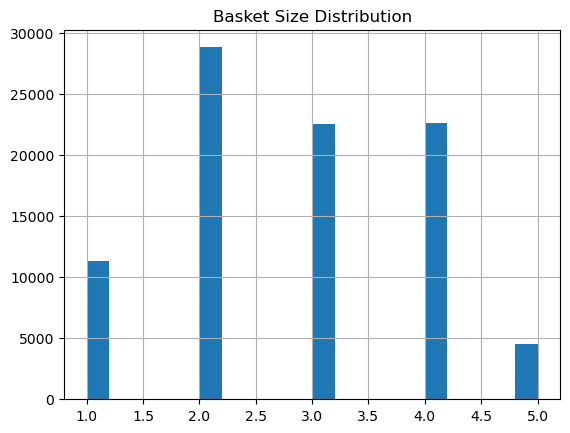

In [56]:
basket_size.hist(bins=20)
plt.title('Basket Size Distribution')
plt.show()

In [57]:
from itertools import combinations
from collections import Counter

pair_counter = Counter()

for basket in df.groupby('TransactionID')['SKU'].apply(list):

    unique_items = list(set(basket))

    for pair in combinations(sorted(unique_items), 2):
        pair_counter[pair] += 1

top_pairs = pd.DataFrame(
    pair_counter.items(),
    columns=['pair','count']
)

top_pairs.sort_values(
    'count',
    ascending=False
).head(20)

,pair,count
12,"(Nabati Drinko Richeese 150ml, Richeese Wafer ...",14499
102,"(Nabati Drinko Richeese 150ml, Nextar Brownies...",1951
10,"(Nabati Drinko Richeese 150ml, Nextar Pineappl...",1950
13,"(Nabati Drinko Richeese 150ml, Richeese Wafer ...",1950
155,"(Nabati Drinko Richeese 150ml, Nabati Drinko R...",1948
97,"(Nabati Drinko Richeese 150ml, Richeese Siip K...",1947
56,"(Richeese Wafer Keju 10g Renceng, Richeese Waf...",1939
178,"(Nabati Drinko Richeese 150ml, Richeese Mi Ins...",1927
59,"(Nabati Biskuit Rasa Kelapa, Richeese Wafer Ke...",1922
11,"(Nabati Drinko Richeese 150ml, Richeese Mi Ins...",1920


In [58]:
promo_rate = (
    df.groupby('SKU')
    ['DiscountPercentage']
    .apply(lambda x: (x > 0).mean())
    .sort_values(ascending=False)
)

promo_rate

SKU
Richeese Wafer Keju 50g              0.764945
Nabati Drinko Richeese 150ml         0.757806
Richoco Wafer Hazelnut 50g           0.449446
Richoco Wafer Cokelat 50g            0.444812
Nabati Biskuit Rasa Cokelat          0.444127
Richeese Siip Keju 20g               0.443910
Nextar Nastar Pie 30g                0.443750
Richoco Wafer Cokelat 10g Renceng    0.442208
Richeese Wafer Keju 10g Renceng      0.441569
Richeese Mi Instan Goreng            0.440045
Nabati Biskuit Rasa Kelapa           0.439762
Richeese Mi Instan Keju Pedas        0.438757
Nextar Pineapple Pie 30g             0.438477
Richoco Ahh! Extruded 15g            0.438037
Nextar Choco Delight 40g             0.437755
Richeese Wafer Pink Lava 50g         0.436180
Nextar Brownies Pie 40g              0.435692
Nabati Drinko Richoco 150ml          0.435326
Richeese Mi Instan Ramen Keju        0.434941
Richeese Siip Jagung Bakar 20g       0.433648
Name: DiscountPercentage, dtype: float64

In [59]:
sku_summary = (
    df.groupby(['SKU','SKU_Category'])
      .agg(
          Revenue=('Total_Price','sum'),
          Qty=('Qty','sum'),
          Transactions=('TransactionID','nunique')
      )
      .reset_index()
)

sku_summary['RevenueShare'] = (
    sku_summary['Revenue']
    / sku_summary['Revenue'].sum()
)

sku_summary.sort_values(
    'Revenue',
    ascending=False
).head(20)

,SKU,SKU_Category,Revenue,Qty,Transactions,RevenueShare
14,Richeese Wafer Keju 50g,Wafer,387670800.0,70534,23603,0.100446
13,Richeese Wafer Keju 10g Renceng,Wafer,322843500.0,34070,11321,0.083649
17,Richoco Wafer Cokelat 10g Renceng,Wafer,318436500.0,33635,11178,0.082507
4,Nextar Brownies Pie 40g,Kue/Pie,250694600.0,34435,11375,0.064955
6,Nextar Nastar Pie 30g,Kue/Pie,243736100.0,33488,11200,0.063152
7,Nextar Pineapple Pie 30g,Kue/Pie,225149700.0,33974,11264,0.058336
5,Nextar Choco Delight 40g,Kue/Pie,218481900.0,32934,11013,0.056609
2,Nabati Drinko Richeese 150ml,Minuman,201151800.0,71902,23923,0.052118
19,Richoco Wafer Hazelnut 50g,Wafer,192448500.0,33879,11285,0.049863
18,Richoco Wafer Cokelat 50g,Wafer,183961700.0,33447,11180,0.047665


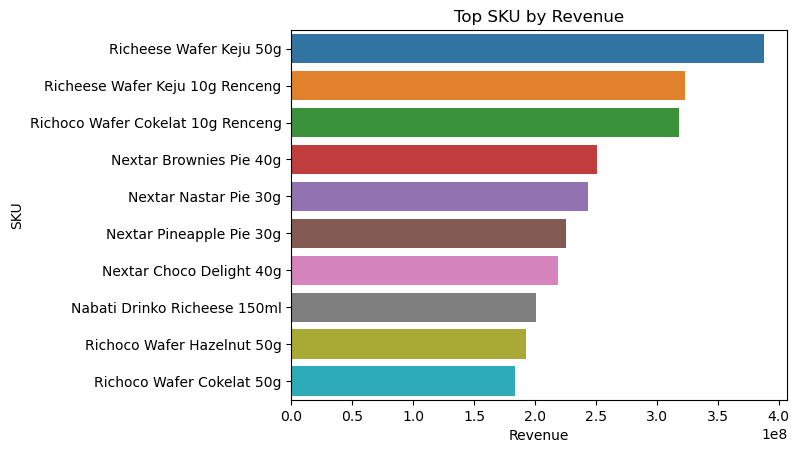

In [60]:
top_sku = sku_summary.sort_values(
    'Revenue',
    ascending=False
).head(10)

sns.barplot(
    data=top_sku,
    x='Revenue',
    y='SKU'
)
plt.title('Top SKU by Revenue')
plt.show()

In [61]:
df['PromoFlag'] = (
    df['DiscountPercentage'] > 0
).astype(int)

promo_lift = (
    df.groupby(['SKU','PromoFlag'])
      ['Qty']
      .mean()
      .unstack()
)

promo_lift.columns = [
    'AvgQty_NoPromo',
    'AvgQty_Promo'
]

promo_lift['Lift'] = (
    promo_lift['AvgQty_Promo']
    /
    promo_lift['AvgQty_NoPromo']
)

promo_lift.sort_values(
    'Lift',
    ascending=False
)

,AvgQty_NoPromo,AvgQty_Promo,Lift
SKU,,,
Richeese Mi Instan Keju Pedas,2.954880,3.006959,1.017625
Richeese Wafer Keju 10g Renceng,2.988295,3.036207,1.016033
Nextar Brownies Pie 40g,3.007166,3.053269,1.015331
Richeese Mi Instan Goreng,3.011550,3.037934,1.008761
Nabati Biskuit Rasa Kelapa,3.003325,3.026024,1.007558
Richoco Wafer Cokelat 10g Renceng,3.000481,3.019826,1.006447
Richeese Siip Jagung Bakar 20g,2.977827,2.991579,1.004618
Nextar Pineapple Pie 30g,3.010119,3.023891,1.004576
Richoco Ahh! Extruded 15g,3.004504,3.015889,1.003790


In [62]:
sku_discount = (
    df.groupby('SKU')
      .agg(
          AvgDiscount=('DiscountPercentage','mean'),
          AvgQty=('Qty','mean')
      )
)

<Axes: xlabel='AvgDiscount', ylabel='AvgQty'>

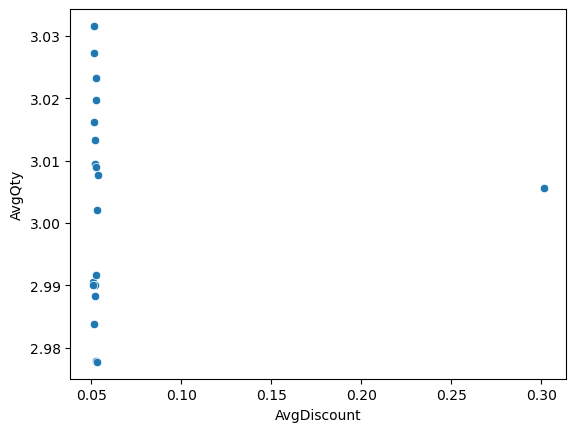

In [63]:
sns.scatterplot(
    data=sku_discount,
    x='AvgDiscount',
    y='AvgQty'
)

In [73]:
promo_impact = (
    df.groupby(['SKU','PromoFlag'])
      ['Qty']
      .mean()
      .unstack()
)

promo_impact['Lift'] = (
    promo_impact[1]
    /
    promo_impact[0]
)

promo_impact.sort_values(
    'Lift',
    ascending=False
)

PromoFlag,0,1,Lift
SKU,,,
Richeese Mi Instan Keju Pedas,2.954880,3.006959,1.017625
Richeese Wafer Keju 10g Renceng,2.988295,3.036207,1.016033
Nextar Brownies Pie 40g,3.007166,3.053269,1.015331
Richeese Mi Instan Goreng,3.011550,3.037934,1.008761
Nabati Biskuit Rasa Kelapa,3.003325,3.026024,1.007558
Richoco Wafer Cokelat 10g Renceng,3.000481,3.019826,1.006447
Richeese Siip Jagung Bakar 20g,2.977827,2.991579,1.004618
Nextar Pineapple Pie 30g,3.010119,3.023891,1.004576
Richoco Ahh! Extruded 15g,3.004504,3.015889,1.003790


In [74]:
df.groupby('SKU_Category')['SKU'].unique()

SKU_Category
Biskuit           [Nabati Biskuit Rasa Cokelat, Nabati Biskuit R...
Extruded Snack    [Richeese Siip Keju 20g, Richoco Ahh! Extruded...
Kue/Pie           [Nextar Brownies Pie 40g, Nextar Nastar Pie 30...
Mi Instan         [Richeese Mi Instan Keju Pedas, Richeese Mi In...
Minuman           [Nabati Drinko Richeese 150ml, Nabati Drinko R...
Wafer             [Richeese Wafer Keju 50g, Richoco Wafer Hazeln...
Name: SKU, dtype: object

In [75]:
weekly = (
    df.groupby([
        pd.Grouper(key='DateTime',freq='W'),
        'SKU'
    ])
    ['Qty']
    .sum()
    .reset_index()
)

In [76]:
target_sku = "Richeese Siip Keju 20g"

In [77]:
basket_size.describe()

count    89892.000000
mean         2.781126
std          1.109278
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max          5.000000
Name: SKU_ID, dtype: float64

In [78]:
top_pairs.sort_values(
    'count',
    ascending=False
).head(20)

,pair,count
12,"(Nabati Drinko Richeese 150ml, Richeese Wafer ...",14499
102,"(Nabati Drinko Richeese 150ml, Nextar Brownies...",1951
10,"(Nabati Drinko Richeese 150ml, Nextar Pineappl...",1950
13,"(Nabati Drinko Richeese 150ml, Richeese Wafer ...",1950
155,"(Nabati Drinko Richeese 150ml, Nabati Drinko R...",1948
97,"(Nabati Drinko Richeese 150ml, Richeese Siip K...",1947
56,"(Richeese Wafer Keju 10g Renceng, Richeese Waf...",1939
178,"(Nabati Drinko Richeese 150ml, Richeese Mi Ins...",1927
59,"(Nabati Biskuit Rasa Kelapa, Richeese Wafer Ke...",1922
11,"(Nabati Drinko Richeese 150ml, Richeese Mi Ins...",1920


In [79]:
promo_lift.sort_values('Lift', ascending=False)

,AvgQty_NoPromo,AvgQty_Promo,Lift
SKU,,,
Richeese Mi Instan Keju Pedas,2.954880,3.006959,1.017625
Richeese Wafer Keju 10g Renceng,2.988295,3.036207,1.016033
Nextar Brownies Pie 40g,3.007166,3.053269,1.015331
Richeese Mi Instan Goreng,3.011550,3.037934,1.008761
Nabati Biskuit Rasa Kelapa,3.003325,3.026024,1.007558
Richoco Wafer Cokelat 10g Renceng,3.000481,3.019826,1.006447
Richeese Siip Jagung Bakar 20g,2.977827,2.991579,1.004618
Nextar Pineapple Pie 30g,3.010119,3.023891,1.004576
Richoco Ahh! Extruded 15g,3.004504,3.015889,1.003790


In [81]:
promo_lift = promo_lift.reset_index()

promo_lift = promo_lift.merge(
    df[['SKU','SKU_Category']]
    .drop_duplicates(),
    on='SKU',
    how='left'
)

promo_lift.sort_values(
    'Lift',
    ascending=False
)

,SKU,AvgQty_NoPromo,AvgQty_Promo,Lift,SKU_Category
9,Richeese Mi Instan Keju Pedas,2.954880,3.006959,1.017625,Mi Instan
13,Richeese Wafer Keju 10g Renceng,2.988295,3.036207,1.016033,Wafer
4,Nextar Brownies Pie 40g,3.007166,3.053269,1.015331,Kue/Pie
8,Richeese Mi Instan Goreng,3.011550,3.037934,1.008761,Mi Instan
1,Nabati Biskuit Rasa Kelapa,3.003325,3.026024,1.007558,Biskuit
17,Richoco Wafer Cokelat 10g Renceng,3.000481,3.019826,1.006447,Wafer
11,Richeese Siip Jagung Bakar 20g,2.977827,2.991579,1.004618,Extruded Snack
7,Nextar Pineapple Pie 30g,3.010119,3.023891,1.004576,Kue/Pie
16,Richoco Ahh! Extruded 15g,3.004504,3.015889,1.003790,Extruded Snack
3,Nabati Drinko Richoco 150ml,3.027180,3.037294,1.003341,Minuman


In [82]:
promo_summary = (
    df.groupby('PromoFlag')
      .agg({
          'Qty':'sum',
          'Total_Price':'sum',
          'TransactionID':'nunique'
      })
)

In [83]:
sku_promo = (
    df.groupby(['SKU','PromoFlag'])
      .agg(
          Qty=('Qty','sum'),
          Revenue=('Total_Price','sum'),
          Transactions=('TransactionID','nunique')
      )
)

In [86]:
df.groupby('SKU_Category')['SKU'].unique()

SKU_Category
Biskuit           [Nabati Biskuit Rasa Cokelat, Nabati Biskuit R...
Extruded Snack    [Richeese Siip Keju 20g, Richoco Ahh! Extruded...
Kue/Pie           [Nextar Brownies Pie 40g, Nextar Nastar Pie 30...
Mi Instan         [Richeese Mi Instan Keju Pedas, Richeese Mi In...
Minuman           [Nabati Drinko Richeese 150ml, Nabati Drinko R...
Wafer             [Richeese Wafer Keju 50g, Richoco Wafer Hazeln...
Name: SKU, dtype: object

In [87]:
top_pairs.sort_values(
    'count',
    ascending=False
).head(20)

,pair,count
12,"(Nabati Drinko Richeese 150ml, Richeese Wafer ...",14499
102,"(Nabati Drinko Richeese 150ml, Nextar Brownies...",1951
10,"(Nabati Drinko Richeese 150ml, Nextar Pineappl...",1950
13,"(Nabati Drinko Richeese 150ml, Richeese Wafer ...",1950
155,"(Nabati Drinko Richeese 150ml, Nabati Drinko R...",1948
97,"(Nabati Drinko Richeese 150ml, Richeese Siip K...",1947
56,"(Richeese Wafer Keju 10g Renceng, Richeese Waf...",1939
178,"(Nabati Drinko Richeese 150ml, Richeese Mi Ins...",1927
59,"(Nabati Biskuit Rasa Kelapa, Richeese Wafer Ke...",1922
11,"(Nabati Drinko Richeese 150ml, Richeese Mi Ins...",1920


In [88]:
category_summary = (
    df.groupby('SKU_Category')
      .agg(
          Revenue=('Total_Price','sum'),
          Qty=('Qty','sum'),
          SKU_Count=('SKU','nunique')
      )
      .sort_values('Revenue', ascending=False)
)

category_summary

,Revenue,Qty,SKU_Count
SKU_Category,,,
Wafer,1.584164e+09,239868,6
Kue/Pie,9.380623e+08,134831,4
Mi Instan,3.523914e+08,101347,3
Extruded Snack,3.343547e+08,101195,3
Minuman,3.307704e+08,106074,2
Biskuit,3.197678e+08,67357,2


In [93]:
wafer_df = df[df['SKU_Category'] == 'Wafer']

wafer_df[['SKU']].drop_duplicates()

,SKU
2,Richeese Wafer Keju 50g
8,Richoco Wafer Hazelnut 50g
9,Richoco Wafer Cokelat 50g
16,Richeese Wafer Pink Lava 50g
21,Richeese Wafer Keju 10g Renceng
22,Richoco Wafer Cokelat 10g Renceng


In [94]:
weekly_qty = (
    wafer_df.groupby([
        pd.Grouper(key='DateTime', freq='W'),
        'SKU'
    ])['Qty']
    .sum()
    .reset_index()
)

In [95]:
wafer_sales = weekly_qty.pivot(
    index='DateTime',
    columns='SKU',
    values='Qty'
)

In [96]:
weekly_promo = (
    wafer_df.groupby([
        pd.Grouper(key='DateTime', freq='W'),
        'SKU'
    ])['DiscountPercentage']
    .mean()
    .reset_index()
)

In [97]:
wafer_promo = weekly_promo.pivot(
    index='DateTime',
    columns='SKU',
    values='DiscountPercentage'
)

In [98]:
results = []

for promo_sku in wafer_promo.columns:

    for sales_sku in wafer_sales.columns:

        if promo_sku == sales_sku:
            continue

        corr = (
            wafer_promo[promo_sku]
            .corr(
                wafer_sales[sales_sku]
            )
        )

        results.append([
            promo_sku,
            sales_sku,
            corr
        ])

cross_effect = pd.DataFrame(
    results,
    columns=[
        'Promo_SKU',
        'Affected_SKU',
        'Correlation'
    ]
)

cross_effect.sort_values(
    'Correlation'
).head(20)

,Promo_SKU,Affected_SKU,Correlation
21,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-0.259219
24,Richoco Wafer Cokelat 50g,Richoco Wafer Hazelnut 50g,-0.244867
20,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 10g Renceng,-0.240926
23,Richoco Wafer Cokelat 50g,Richoco Wafer Cokelat 10g Renceng,-0.228098
22,Richoco Wafer Cokelat 50g,Richeese Wafer Pink Lava 50g,-0.216535
15,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Keju 10g Renceng,-0.090098
0,Richeese Wafer Keju 10g Renceng,Richeese Wafer Keju 50g,-0.088937
2,Richeese Wafer Keju 10g Renceng,Richoco Wafer Cokelat 10g Renceng,-0.078818
3,Richeese Wafer Keju 10g Renceng,Richoco Wafer Cokelat 50g,-0.071746
19,Richoco Wafer Cokelat 10g Renceng,Richoco Wafer Hazelnut 50g,-0.068566


In [99]:
cross_effect.sort_values(
    'Correlation'
).head(20)

,Promo_SKU,Affected_SKU,Correlation
21,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 50g,-0.259219
24,Richoco Wafer Cokelat 50g,Richoco Wafer Hazelnut 50g,-0.244867
20,Richoco Wafer Cokelat 50g,Richeese Wafer Keju 10g Renceng,-0.240926
23,Richoco Wafer Cokelat 50g,Richoco Wafer Cokelat 10g Renceng,-0.228098
22,Richoco Wafer Cokelat 50g,Richeese Wafer Pink Lava 50g,-0.216535
15,Richoco Wafer Cokelat 10g Renceng,Richeese Wafer Keju 10g Renceng,-0.090098
0,Richeese Wafer Keju 10g Renceng,Richeese Wafer Keju 50g,-0.088937
2,Richeese Wafer Keju 10g Renceng,Richoco Wafer Cokelat 10g Renceng,-0.078818
3,Richeese Wafer Keju 10g Renceng,Richoco Wafer Cokelat 50g,-0.071746
19,Richoco Wafer Cokelat 10g Renceng,Richoco Wafer Hazelnut 50g,-0.068566


In [100]:
wafer_df.groupby('SKU')['DiscountPercentage'].describe()

,count,mean,std,min,25%,50%,75%,max
SKU,,,,,,,,
Richeese Wafer Keju 10g Renceng,11321.0,0.052098,0.079521,0.0,0.00,0.00,0.10,0.3
Richeese Wafer Keju 50g,23603.0,0.051862,0.053115,0.0,0.05,0.05,0.05,0.3
Richeese Wafer Pink Lava 50g,11360.0,0.052711,0.081155,0.0,0.00,0.00,0.10,0.3
Richoco Wafer Cokelat 10g Renceng,11178.0,0.052823,0.080240,0.0,0.00,0.00,0.10,0.3
Richoco Wafer Cokelat 50g,11180.0,0.052598,0.079774,0.0,0.00,0.00,0.10,0.3
Richoco Wafer Hazelnut 50g,11285.0,0.052960,0.080030,0.0,0.00,0.00,0.10,0.3


In [101]:
cannibal_score = (
    cross_effect.groupby('Promo_SKU')
    ['Correlation']
    .mean()
    .sort_values()
)

cannibal_score

Promo_SKU
Richoco Wafer Cokelat 50g           -0.237929
Richeese Wafer Keju 10g Renceng     -0.073359
Richoco Wafer Cokelat 10g Renceng   -0.063043
Richeese Wafer Keju 50g              0.029398
Richoco Wafer Hazelnut 50g           0.204825
Richeese Wafer Pink Lava 50g         0.225244
Name: Correlation, dtype: float64

In [102]:
wafer_df.groupby('SKU').agg(
    Revenue=('Total_Price','sum'),
    Qty=('Qty','sum')
).sort_values('Revenue', ascending=False)

,Revenue,Qty
SKU,,
Richeese Wafer Keju 50g,387670800.0,70534
Richeese Wafer Keju 10g Renceng,322843500.0,34070
Richoco Wafer Cokelat 10g Renceng,318436500.0,33635
Richoco Wafer Hazelnut 50g,192448500.0,33879
Richoco Wafer Cokelat 50g,183961700.0,33447
Richeese Wafer Pink Lava 50g,178802800.0,34303


In [103]:
df['PromoFlag'] = (
    df['DiscountPercentage'] > 0
).astype(int)

df['PromoFlag'].value_counts(normalize=True)

PromoFlag
1    0.501022
0    0.498978
Name: proportion, dtype: float64

In [104]:
df.groupby('PromoFlag')['Total_Price'].agg([
    'count',
    'sum',
    'mean',
    'median'
])

,count,sum,mean,median
PromoFlag,,,,
0,124745,2.095883e+09,16801.338731,15000.0
1,125256,1.763627e+09,14080.182985,11600.0


In [105]:
df.groupby('PromoFlag')['Qty'].agg([
    'count',
    'sum',
    'mean',
    'median'
])

,count,sum,mean,median
PromoFlag,,,,
0,124745,374447,3.001699,3.0
1,125256,376225,3.003649,3.0


In [106]:
revenue_compare = (
    df.groupby(['SKU','PromoFlag'])['Total_Price']
      .sum()
      .unstack()
)

revenue_compare.columns = [
    'Revenue_NoPromo',
    'Revenue_Promo'
]

revenue_compare['PromoShare'] = (
    revenue_compare['Revenue_Promo']
    /
    (
        revenue_compare['Revenue_Promo']
        +
        revenue_compare['Revenue_NoPromo']
    )
)

revenue_compare.sort_values(
    'PromoShare',
    ascending=False
)

,Revenue_NoPromo,Revenue_Promo,PromoShare
SKU,,,
Richeese Wafer Keju 50g,96289300.0,291381500.0,0.751621
Nabati Drinko Richeese 150ml,69964000.0,131187800.0,0.652183
Richoco Wafer Hazelnut 50g,112014000.0,80434500.0,0.417953
Richeese Wafer Keju 10g Renceng,188920000.0,133923500.0,0.414825
Richoco Wafer Cokelat 50g,107693700.0,76268000.0,0.414586
Richoco Wafer Cokelat 10g Renceng,187080000.0,131356500.0,0.412505
Nabati Biskuit Rasa Kelapa,94830000.0,66480700.0,0.412128
Richeese Mi Instan Keju Pedas,64638000.0,45277300.0,0.411929
Richeese Mi Instan Goreng,67532500.0,47258400.0,0.411691
